In [117]:
# Executa a extração dos dados
from src.extract.baixar_arquivo import DengueBeloHorizonte
print("=== Iniciando o Pipeline de Dados da Dengue ===")

try:
    print("✅ Iniciando Extração de Dados!")
    dengue_extract = DengueBeloHorizonte()
    dengue_extract.download_dengue_json(year=2026)
    print("✅ Processo de Extração concluído!")
except Exception as e:
    print(f"❌ Erro durante o Extração de Dados: {e}")



=== Iniciando o Pipeline de Dados da Dengue ===
✅ Iniciando Extração de Dados!


10337721it [00:00, 10430489425.35it/s]


✅ Exportando 4176 registros para /home/marilan/gitmatheus/projeto/projeto/data/raw/dengue_bh.json...
✅ Processo de Extração concluído!


In [118]:
# Executa a transformação dos dados
from src.load.salva_arquivo_csv import SalvarArquivoCSV

try:
    load = SalvarArquivoCSV()
    load.salva_arquivo_processado()
    print("✅ Processo de tratamento/load concluído!")
except Exception as e:
    print(f"❌ Erro durante o tratamento/load de Dados: {e}")


✅ Tamanho do df: 4176 registros.
✅ Arquivo salvo com sucesso em /home/marilan/gitmatheus/projeto/projeto/data/processed/dengue_bh_tratado.csv
✅ Processo de tratamento/load concluído!


In [119]:
# Definindo os data datypes de colunas

dtypes = {
    'sexo': 'str',
    'id_estado_gestacional': 'Int64',
    'ind_febre': 'Int64',
    'ind_mialgia': 'Int64',
    'ind_cefaleia': 'Int64',
    'ind_exantema': 'Int64',
    'ind_vomito': 'Int64',
    'ind_nausea': 'Int64',
    'ind_dor_costas': 'Int64',
    'ind_conjuntivite': 'Int64',
    'ind_artrite': 'Int64',
    'ind_artralgia': 'Int64',
    'ind_petequia': 'Int64',
    'ind_leucopenia': 'Int64',
    'ind_prova_laco': 'Int64',
    'ind_dor_retroorbital': 'Int64',
    'id_classificacao': 'Int64',
    'genero': 'str',
    'estado_gestacional': 'str',
}

In [ ]:
# Importa as bibliotecas para analise exploratoria.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Lendo o arquivo
df = pd.read_csv('./projeto/data/processed/dengue_bh_tratado.csv', sep=',', dtype=dtypes)

# Graficos configurados e disponibilizados em functions.
def grafico_pizza_por_genero (df: pd.DataFrame):
    df_genero = df.groupby('genero').agg(total_por_genero=('genero','count')).sort_values(by='total_por_genero',ascending=False).reset_index()
    plt.pie(x=df_genero['total_por_genero'], labels=df_genero['genero'], colors=['#e37fe1','#5145a8'],autopct='%1.2f%%')
    plt.show()
    print(f"O gênero {df_genero['genero'].loc[0]} é a maioria de casos de dengue no municipio de Belo Horizonte-MG em 2026, tendo {df_genero['total_por_genero'].loc[0]} dos casos registrado!")

def grafico_barra_sintomas_por_genero(df: pd.DataFrame):
    print('Comparação de sintomas entre Homens vs Mulheres')
    colunas_sintomas = [
        'ind_febre','ind_mialgia', 'ind_cefaleia', 'ind_exantema',
        'ind_vomito', 'ind_nausea', 'ind_dor_costas', 'ind_conjuntivite',
        'ind_artrite', 'ind_artralgia', 'ind_petequia', 'ind_leucopenia',
        'ind_prova_laco', 'ind_dor_retroorbital'
    ]

    resultado = {}
    for coluna in colunas_sintomas:
        # Mantém apenas respostas válidas
        df_valido = df[df[coluna].isin([1, 2])]

        # Calcula % de presença do sintoma
        percentual = (
            df_valido
            .groupby('genero')[coluna]
            .apply(lambda x: (x == 1).mean() * 100)
            .round(2)
        )

        resultado[coluna.replace('ind_', '')] = percentual

    df_comparativo = pd.DataFrame(resultado).T
    ax = df_comparativo.plot(
        kind='bar',
        figsize=(14, 7),
        width=0.8,
        color=['#FF69B4', '#1E90FF']
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

    plt.title('Comparação de Sintomas de Dengue por Gênero (%)', fontsize=16)
    plt.xlabel('Sintomas', fontsize=12)
    plt.ylabel('Frequência Relativa (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Gênero')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def grafico_radar_estado_gestacional(df: pd.DataFrame):
    df_gestacional =  df.where(df['sexo'] == 'F').groupby(by='estado_gestacional').agg(quantidade=('estado_gestacional','count')).reset_index()
    df_gestacional = df_gestacional[~df_gestacional['estado_gestacional'].isin(['Não','Ignorado', 'Não se aplica'])]

    maior_estado = df_gestacional.loc[df_gestacional['quantidade'].idxmax(), 'estado_gestacional']
    print(f'Para os casos onde a gravidez é preenchida, nota-se um aumento em casos de dengue no {maior_estado}')

    labels = df_gestacional['estado_gestacional'].tolist()
    values = df_gestacional['quantidade'].tolist()

    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    values += values[:1]
    angles += angles[:1]
    labels_closed = labels + [labels[0]]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.fill(angles, values, color='#636EFA', alpha=0.3)
    ax.plot(angles, values, color='#636EFA', linewidth=2, marker='o')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.spines['polar'].set_visible(False) 
    plt.title('Distribuição Gestacional (Quantidade)', size=15, color='#333', y=1.1)
    plt.show()

In [121]:
# (Qtd de linhas X Qtd de colunas)
df.shape

(4176, 18)

In [122]:
# Informação detalhadas sobre as colunas.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4176 entries, 0 to 4175
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   sexo                   4176 non-null   object
 1   id_estado_gestacional  4176 non-null   Int64 
 2   ind_febre              4142 non-null   Int64 
 3   ind_mialgia            4142 non-null   Int64 
 4   ind_cefaleia           4142 non-null   Int64 
 5   ind_exantema           4142 non-null   Int64 
 6   ind_vomito             4142 non-null   Int64 
 7   ind_nausea             4142 non-null   Int64 
 8   ind_dor_costas         4142 non-null   Int64 
 9   ind_conjuntivite       4142 non-null   Int64 
 10  ind_artrite            4142 non-null   Int64 
 11  ind_artralgia          4142 non-null   Int64 
 12  ind_petequia           4142 non-null   Int64 
 13  ind_leucopenia         4142 non-null   Int64 
 14  ind_prova_laco         4142 non-null   Int64 
 15  ind_dor_retroorbital 

In [123]:
# resumo das estatísticas descritivas
df.describe()

,id_estado_gestacional,ind_febre,ind_mialgia,ind_cefaleia,ind_exantema,ind_vomito,ind_nausea,ind_dor_costas,ind_conjuntivite,ind_artrite,ind_artralgia,ind_petequia,ind_leucopenia,ind_prova_laco,ind_dor_retroorbital
count,4176.0,4142.0,4142.0,4142.0,4142.0,4142.0,4142.0,4142.0,4142.0,4142.0,4142.0,4142.0,4142.0,4142.0,4142.0
mean,5.885057,1.164172,1.190488,1.206422,1.899807,1.678416,1.512313,1.661275,1.975857,1.886045,1.802752,1.95099,1.974891,1.955094,1.569049
std,1.24206,0.370476,0.392733,0.404786,0.300294,0.467141,0.499909,0.473333,0.153511,0.317794,0.397969,0.215915,0.156474,0.207122,0.495269
min,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,5.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0
50%,6.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
75%,6.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
max,9.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [124]:
# Campo essencial para a EDA, não podendo haver valores nulos
df['sexo'].isna().value_counts()

sexo
False    4176
Name: count, dtype: int64

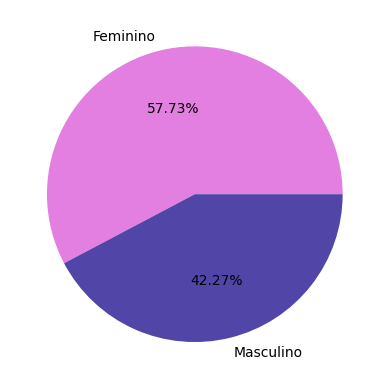

O gênero Feminino é a maioria de casos de dengue no municipio de Belo Horizonte-MG em 2026, tendo 2411 dos casos registrado!


In [125]:
grafico_pizza_por_genero(df)

Para os casos onde a gravidez é preenchida, nota-se um aumento em casos de dengue no 2ºTrimestre


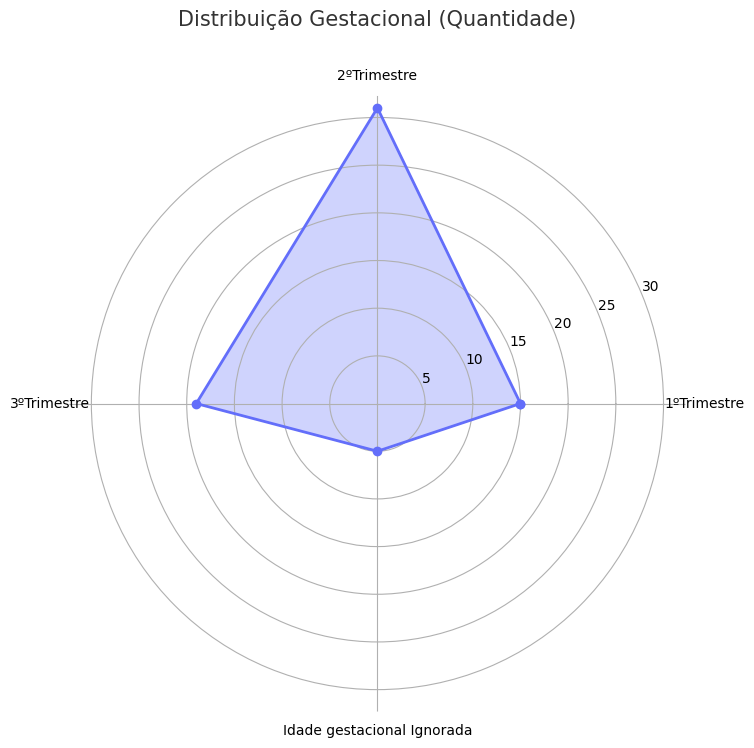

In [126]:
grafico_radar_estado_gestacional(df=df)

Comparação de sintomas entre Homens vs Mulheres


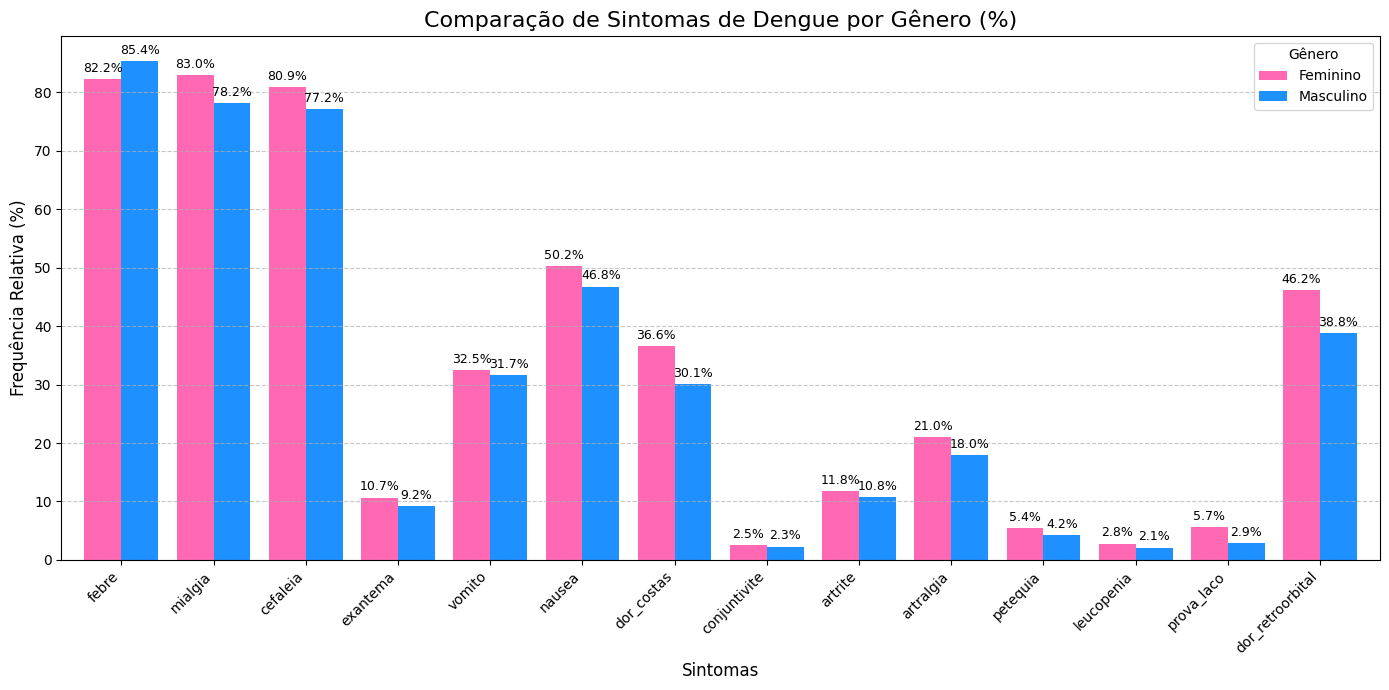

In [127]:
grafico_barra_sintomas_por_genero(df=df)